Step 3: Displaying Initial Network...


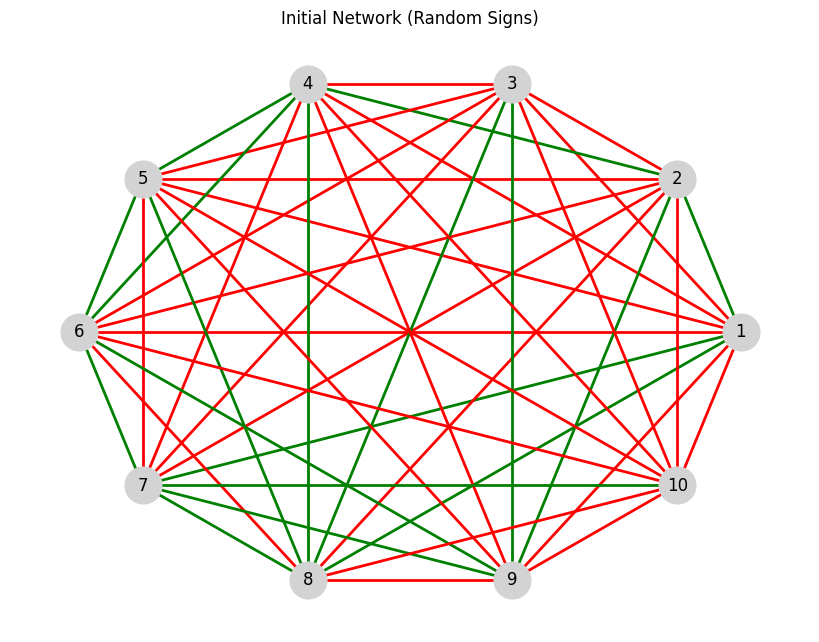

Initial Unstable Triangles: 64
Network Stabilized.
Coalition 1: [1, 2, 4, 5, 6, 8, 10]
Coalition 2: [9, 3, 7]


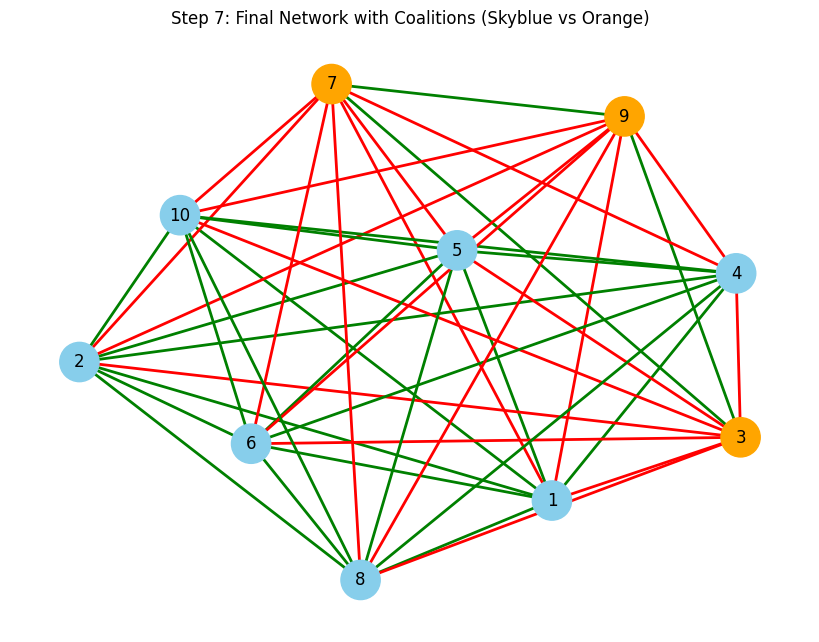

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import itertools

def implement_social_balance():
    # --- STEP 1 ---
    # Create a graph with 10 nodes (representing countries).
    G = nx.Graph()
    nodes = list(range(1, 11))
    G.add_nodes_from(nodes)

    # --- STEP 2 ---
    # Make it a complete graph (K_10) and assign '+' or '-' signs randomly.
    # Formula for number of edges in complete graph: n(n-1)/2
    all_possible_edges = list(itertools.combinations(nodes, 2))
    for u, v in all_possible_edges:
        G.add_edge(u, v, sign=random.choice(['+', '-']))

    # --- STEP 3 ---
    # Display the network (Initial state)
    def display_network(graph, title):
        plt.figure(figsize=(8, 6))
        pos = nx.circular_layout(graph)
        # Green for '+', Red for '-'
        colors = ['green' if graph[u][v]['sign'] == '+' else 'red' for u, v in graph.edges()]
        nx.draw(G, pos, with_labels=True, node_color='lightgray',
                edge_color=colors, width=2, node_size=700)
        plt.title(title)
        plt.show()

    print("Step 3: Displaying Initial Network...")
    display_network(G, "Initial Network (Random Signs)")

    # --- STEP 4.1 & 4.2 ---
    # Get all triangles and store sign details.
    # A triangle (i, j, k) is defined by three distinct nodes and the edges between them.
    def get_all_triangles(graph):
        return list(itertools.combinations(graph.nodes(), 3))

    def get_triangle_signs(graph, tri):
        s1 = graph[tri[0]][tri[1]]['sign']
        s2 = graph[tri[1]][tri[2]]['sign']
        s3 = graph[tri[2]][tri[0]]['sign']
        return [s1, s2, s3]

    # --- STEP 4.3 ---
    # Count unstable triangles.
    # FORMULA FOR STABILITY:
    # A triangle is STABLE if (sign1 * sign2 * sign3) == '+'
    # Stable: (+,+,+) or (+,-,-)
    # Unstable: (+,+,-) or (-,-,-)
    def get_unstable_triangles(graph):
        triangles = get_all_triangles(graph)
        unstable = []
        for tri in triangles:
            signs = get_triangle_signs(graph, tri)
            if signs.count('-') % 2 != 0: # Odd number of '-' means unstable
                unstable.append(tri)
        return unstable

    # --- STEP 5 ---
    # While the number of unstable triangles is not zero:
    unstable_list = get_unstable_triangles(G)
    print(f"Initial Unstable Triangles: {len(unstable_list)}")

    while len(unstable_list) > 0:
        # Step 5.1: Choose an unstable triangle
        tri = random.choice(unstable_list)

        # Step 5.2: Make that triangle stable.
        # We achieve stability by flipping the sign of one random edge in the triangle.
        u, v = random.choice([(tri[0], tri[1]), (tri[1], tri[2]), (tri[2], tri[0])])
        G[u][v]['sign'] = '-' if G[u][v]['sign'] == '+' else '+'

        # Step 5.3: Recalculate unstable triangles
        unstable_list = get_unstable_triangles(G)

    print("Network Stabilized.")

    # --- STEP 6 ---
    # Divide into two coalitions.
    # Logic: Intra-edges (within group) are '+', Inter-edges (between groups) are '-'.
    coalition1 = []
    coalition2 = []
    unprocessed_nodes = []

    # Step 6.1: Choose random node and add to first coalition.
    start_node = random.choice(nodes)
    coalition1.append(start_node)
    unprocessed_nodes.append(start_node)

    processed = []

    # Step 6.4: Repeat for all 'unprocessed' nodes of first coalition.
    while len(unprocessed_nodes) > 0:
        curr = unprocessed_nodes.pop(0)
        if curr in processed:
            continue

        for neighbor in nodes:
            if neighbor != curr:
                sign = G[curr][neighbor]['sign']
                # Step 6.2: 'Friends' (+) go to the same coalition
                if sign == '+':
                    if neighbor not in coalition1:
                        coalition1.append(neighbor)
                        unprocessed_nodes.append(neighbor)
                # Step 6.3: 'Enemies' (-) go to the second coalition
                else:
                    if neighbor not in coalition2:
                        coalition2.append(neighbor)

        processed.append(curr)

    # Ensure all nodes are accounted for (in case of isolated structures)
    coalition1 = list(set(coalition1))
    coalition2 = list(set(nodes) - set(coalition1))

    print(f"Coalition 1: {coalition1}")
    print(f"Coalition 2: {coalition2}")

    # --- STEP 7 ---
    # Display the network with coalitions.
    # Nodes in Coalition 1 will be 'skyblue', Coalition 2 will be 'orange'.
    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G)

    node_colors = []
    for n in G.nodes():
        if n in coalition1:
            node_colors.append('skyblue')
        else:
            node_colors.append('orange')

    edge_colors = ['green' if G[u][v]['sign'] == '+' else 'red' for u, v in G.edges()]

    nx.draw(G, pos, with_labels=True, node_color=node_colors,
            edge_color=edge_colors, width=2, node_size=800)
    plt.title("Step 7: Final Network with Coalitions (Skyblue vs Orange)")
    plt.show()

# Run the implementation
implement_social_balance()